# Final Model Evaluation

Notebook này tiếp nối từ `13_lightgbm_catboost_hyperparameter_tuning.ipynb`.

## Objective

Notebook này đánh giá sâu final candidate được chọn từ notebook 13 và quyết định model cuối cùng để dùng cho web/backend.

Notebook 13 chọn model dựa trên Stratified KFold mean RMSE. Tuy nhiên holdout result có thể chưa hoàn toàn đồng thuận, nên notebook này kiểm tra lại bằng holdout diagnostics, segment-level errors, large-error cases, residual behavior và feature importance.

Notebook này không tuning thêm hyperparameter.

Output quan trọng nhất của notebook này là production-ready model được lưu tại:

`models/final_laptop_price_model.joblib`

kèm metadata/schema để web/backend biết cách load model và truyền input đúng format.

## Imports & Config

In [ ]:
import json
import joblib
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
    max_error,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [ ]:
RANDOM_STATE = 42
TEST_SIZE = 0.20

current_path = Path.cwd().resolve()
if (current_path / "data" / "processed" / "final_dataset.csv").exists():
    PROJECT_ROOT = current_path
elif current_path.name == "modeling" and current_path.parent.name == "notebooks":
    PROJECT_ROOT = current_path.parents[1]
else:
    PROJECT_ROOT = current_path

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset.csv"

ROOT_DIR = PROJECT_ROOT
TUNING_DIR = ROOT_DIR / "artifacts" / "hyperparameter_tuning"
TUNING_MODEL_DIR = TUNING_DIR / "models"
TUNING_PARAM_DIR = TUNING_DIR / "params"

EVAL_DIR = ROOT_DIR / "artifacts" / "final_model_evaluation"
MODEL_DIR = EVAL_DIR / "models"
EVAL_METRIC_DIR = EVAL_DIR / "metrics"
EVAL_PRED_DIR = EVAL_DIR / "predictions"
EVAL_PLOT_DIR = EVAL_DIR / "plots"
EVAL_REPORT_DIR = EVAL_DIR / "reports"

for d in [
    MODEL_DIR,
    EVAL_METRIC_DIR,
    EVAL_PRED_DIR,
    EVAL_PLOT_DIR,
    EVAL_REPORT_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data path: {DATA_PATH}")
print(f"Production model directory: {MODEL_DIR}")
print(f"Evaluation directory: {EVAL_DIR}")

Project root: Y:\Python\Laptop-Price-Prediction
Data path: Y:\Python\Laptop-Price-Prediction\data\processed\final_dataset.csv
Production model directory: Y:\Python\Laptop-Price-Prediction\models
Evaluation directory: Y:\Python\Laptop-Price-Prediction\artifacts\final_model_evaluation


## Recreate Holdout Split

Notebook này dùng lại cùng rule split với notebook 13: stratified holdout split theo quantile price segment.

Điều này đảm bảo kết quả holdout evaluation trong notebook 14 có thể so sánh trực tiếp với notebook 13.

In [ ]:
df = pd.read_csv(DATA_PATH)

TARGET_COL = "target_price"
DROP_TARGET_COLS = ["target_price", "log_target_price"]

if TARGET_COL not in df.columns:
    raise ValueError(f"Missing target column: {TARGET_COL}")

X = df.drop(
    columns=[c for c in DROP_TARGET_COLS if c in df.columns],
    errors="ignore",
)

X = X.select_dtypes(include=[np.number]).copy()
y = df[TARGET_COL].copy()

feature_names = X.columns.tolist()

if X.empty:
    raise ValueError("Feature matrix is empty after selecting numeric features.")

price_segment_holdout = pd.qcut(
    y,
    q=5,
    labels=False,
    duplicates="drop",
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=price_segment_holdout,
)

print("Dataset shape:", df.shape)
print("Feature matrix:", X.shape)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Number of features:", len(feature_names))

Dataset shape: (7296, 88)
Feature matrix: (7296, 86)
Train shape: (5836, 86)
Test shape: (1460, 86)
Number of features: 86


## Load Selected Model Metadata

In [ ]:
final_selection_path = TUNING_PARAM_DIR / "final_model_selection.json"

if not final_selection_path.exists():
    raise FileNotFoundError(f"Missing final model selection file: {final_selection_path}")

with open(final_selection_path, "r", encoding="utf-8") as f:
    final_model_selection = json.load(f)

final_model_selection

{'selected_model_name': 'CatBoost',
 'selected_version': 'tuned',
 'selection_basis': 'Stratified KFold mean RMSE',
 'mean_rmse': 5.2255906785150135,
 'std_rmse': 0.26300133206309273,
 'mean_mae': 3.183990923288797,
 'std_mae': 0.1136997060615585,
 'mean_mape_pct': 30.672717590462526,
 'std_mape_pct': 0.9688276776978106,
 'candidate_status': 'primary_candidate',
 'reason': 'Best mean RMSE across Stratified KFold and stable fold-to-fold performance.',
 'selected_model_path': 'Y:\\Python\\Laptop-Price-Prediction\\artifacts\\hyperparameter_tuning\\models\\selected_final_candidate_model.pkl',
 'cv_data_scope': 'training_set_only',
 'holdout_usage': 'independent_sanity_check'}

In [ ]:
required_selection_keys = [
    "selected_model_name",
    "selected_version",
    "selection_basis",
    "selected_model_path",
]

for key in required_selection_keys:
    if key not in final_model_selection:
        raise ValueError(f"Missing key in final_model_selection.json: {key}")

## Load Candidate Models

In [ ]:
candidate_model_paths = {
    "LightGBM_baseline": TUNING_MODEL_DIR / "lightgbm_target_price_baseline.pkl",
    "LightGBM_tuned": TUNING_MODEL_DIR / "lightgbm_target_price_tuned.pkl",
    "CatBoost_baseline": TUNING_MODEL_DIR / "catboost_target_price_baseline.pkl",
    "CatBoost_tuned": TUNING_MODEL_DIR / "catboost_target_price_tuned.pkl",
}

candidate_models = {}

for label, path in candidate_model_paths.items():
    if path.exists():
        candidate_models[label] = joblib.load(path)
        print(f"Loaded {label}: {path}")
    else:
        print(f"Missing model file, skipped {label}: {path}")

if not candidate_models:
    raise FileNotFoundError("No candidate models were loaded.")

Loaded LightGBM_baseline: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\models\lightgbm_target_price_baseline.pkl
Loaded LightGBM_tuned: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\models\lightgbm_target_price_tuned.pkl
Loaded CatBoost_baseline: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\models\catboost_target_price_baseline.pkl
Loaded CatBoost_tuned: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\models\catboost_target_price_tuned.pkl


In [ ]:
selected_model_label = (
    final_model_selection["selected_model_name"]
    + "_"
    + final_model_selection["selected_version"]
)

if selected_model_label not in candidate_models:
    selected_model_path = Path(final_model_selection["selected_model_path"])
    candidate_models[selected_model_label] = joblib.load(selected_model_path)
    print(f"Loaded selected model from metadata: {selected_model_path}")

print("Selected model label:", selected_model_label)

Selected model label: CatBoost_tuned


## Metric Helper Functions

In [ ]:
def safe_mape_pct(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def safe_ape_pct(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    ape = np.full(shape=len(y_true), fill_value=np.nan, dtype=float)
    mask = y_true != 0
    ape[mask] = np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]) * 100

    return ape


def evaluate_regression(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    residual = y_true - y_pred

    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred),
        "mape_pct": safe_mape_pct(y_true, y_pred),
        "median_ae": median_absolute_error(y_true, y_pred),
        "max_error": max_error(y_true, y_pred),
        "mean_residual": np.mean(residual),
        "median_residual": np.median(residual),
    }

## Holdout Evaluation For All Candidates

In [ ]:
metric_rows = []
prediction_frames = []

for model_label, model in candidate_models.items():
    print(f"Evaluating model: {model_label}")

    y_pred = model.predict(X_test)
    metrics = evaluate_regression(y_test, y_pred)

    metric_rows.append({
        "model_label": model_label,
        **metrics,
    })

    residual = y_test.values - y_pred

    pred_df = pd.DataFrame({
        "sample_index": X_test.index,
        "actual_price": y_test.values,
        "predicted_price": y_pred,
        "residual": residual,
        "abs_error": np.abs(residual),
        "ape_pct": safe_ape_pct(y_test.values, y_pred),
        "model_label": model_label,
    })

    prediction_frames.append(pred_df)

final_holdout_metrics_df = (
    pd.DataFrame(metric_rows)
    .sort_values(["rmse", "mae", "mape_pct"])
    .reset_index(drop=True)
)

final_predictions_df = (
    pd.concat(prediction_frames, axis=0)
    .reset_index(drop=True)
)

display(final_predictions_df.head())

final_holdout_metrics_df.to_csv(
    EVAL_METRIC_DIR / "final_holdout_metrics.csv",
    index=False,
)

final_predictions_df.to_csv(
    EVAL_PRED_DIR / "final_holdout_predictions.csv",
    index=False,
)

Evaluating model: LightGBM_baseline
Evaluating model: LightGBM_tuned
Evaluating model: CatBoost_baseline
Evaluating model: CatBoost_tuned


,model_label,mae,rmse,r2,mape_pct,median_ae,max_error,mean_residual,median_residual
0,LightGBM_baseline,3.3666,5.7849,0.8559,31.9004,1.9176,51.6980,-0.0590,-0.2089
1,CatBoost_baseline,3.4741,5.8193,0.8542,33.5088,2.0580,51.9096,-0.0410,-0.3530
2,LightGBM_tuned,3.3703,5.8423,0.8531,31.6658,1.8741,51.8173,-0.0470,-0.2793
3,CatBoost_tuned,3.3726,5.9127,0.8495,32.2540,1.9429,56.1713,-0.0644,-0.2490


,sample_index,actual_price,predicted_price,residual,abs_error,ape_pct,model_label
0,2529,5.8000,7.0477,-1.2477,1.2477,21.5115,LightGBM_baseline
1,4044,5.0000,4.6168,0.3832,0.3832,7.6636,LightGBM_baseline
2,3208,6.7000,8.6741,-1.9741,1.9741,29.4647,LightGBM_baseline
3,7104,26.8900,25.5418,1.3482,1.3482,5.0139,LightGBM_baseline
4,6154,22.9800,36.2767,-13.2967,13.2967,57.8620,LightGBM_baseline


## Selected Model vs Strongest Challenger

In [ ]:
best_holdout_label = final_holdout_metrics_df.iloc[0]["model_label"]

selected_metrics = final_holdout_metrics_df[
    final_holdout_metrics_df["model_label"] == selected_model_label
].iloc[0]

best_holdout_metrics = final_holdout_metrics_df[
    final_holdout_metrics_df["model_label"] == best_holdout_label
].iloc[0]

selected_vs_challenger_df = pd.DataFrame([{
    "selected_model": selected_model_label,
    "best_holdout_model": best_holdout_label,
    "delta_rmse_selected_minus_best_holdout": selected_metrics["rmse"] - best_holdout_metrics["rmse"],
    "delta_mae_selected_minus_best_holdout": selected_metrics["mae"] - best_holdout_metrics["mae"],
    "delta_mape_selected_minus_best_holdout": selected_metrics["mape_pct"] - best_holdout_metrics["mape_pct"],
    "delta_r2_selected_minus_best_holdout": selected_metrics["r2"] - best_holdout_metrics["r2"],
}])

display(selected_vs_challenger_df)

selected_vs_challenger_df.to_csv(
    EVAL_METRIC_DIR / "selected_vs_challenger.csv",
    index=False,
)

,selected_model,best_holdout_model,delta_rmse_selected_minus_best_holdout,delta_mae_selected_minus_best_holdout,delta_mape_selected_minus_best_holdout,delta_r2_selected_minus_best_holdout
0,CatBoost_tuned,LightGBM_baseline,0.1279,0.0060,0.3536,-0.0064


## Price Segment Evaluation

In [ ]:
def add_price_segment(pred_df, q=5):
    out = pred_df.copy()

    out["price_segment"] = pd.qcut(
        out["actual_price"],
        q=q,
        labels=False,
        duplicates="drop",
    )

    out["price_segment"] = "Q" + (out["price_segment"].astype(int) + 1).astype(str)

    return out


segmented_predictions_df = add_price_segment(final_predictions_df, q=5)

segment_metrics_df = (
    segmented_predictions_df
    .groupby(["model_label", "price_segment"], observed=False)
    .agg(
        n_samples=("actual_price", "size"),
        mean_actual_price=("actual_price", "mean"),
        mae=("abs_error", "mean"),
        median_ae=("abs_error", "median"),
        rmse=("residual", lambda x: np.sqrt(np.mean(np.square(x)))),
        mape_pct=("ape_pct", "mean"),
        max_abs_error=("abs_error", "max"),
        mean_residual=("residual", "mean"),
    )
    .reset_index()
)

display(segment_metrics_df)

segment_metrics_df.to_csv(
    EVAL_METRIC_DIR / "segment_holdout_metrics.csv",
    index=False,
)

,model_label,price_segment,n_samples,mean_actual_price,mae,median_ae,rmse,mape_pct,max_abs_error,mean_residual
0,CatBoost_baseline,Q1,292,3.0843,1.8806,1.4005,2.7793,72.7453,16.7915,-1.6706
1,CatBoost_baseline,Q2,292,6.3667,1.7880,1.1860,2.7042,28.2221,11.6381,-0.9030
2,CatBoost_baseline,Q3,293,10.4469,2.8392,2.3303,3.9558,27.5056,26.6951,-0.5750
3,CatBoost_baseline,Q4,291,16.7057,3.2086,2.3219,4.3210,19.1580,16.2697,-0.2530
4,CatBoost_baseline,Q5,292,38.0183,7.6554,5.3123,10.9532,19.8842,51.9096,3.1976
5,CatBoost_tuned,Q1,292,3.0843,1.8263,1.2909,2.8053,69.8159,17.1283,-1.5087
6,CatBoost_tuned,Q2,292,6.3667,1.7223,1.0830,2.5746,27.4895,11.8387,-0.8823
7,CatBoost_tuned,Q3,293,10.4469,2.7061,2.2031,3.9273,26.2743,29.0903,-0.4781
8,CatBoost_tuned,Q4,291,16.7057,3.0427,2.2113,4.2341,18.3340,20.6968,-0.1005
9,CatBoost_tuned,Q5,292,38.0183,7.5669,5.2986,11.2677,19.3292,56.1713,2.6489


## Overprediction / Underprediction Analysis

In [ ]:
bias_summary_df = (
    final_predictions_df
    .assign(
        error_direction=lambda d: np.where(
            d["residual"] > 0,
            "underprediction",
            np.where(d["residual"] < 0, "overprediction", "exact")
        )
    )
    .groupby(["model_label", "error_direction"])
    .agg(
        n_samples=("actual_price", "size"),
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        mean_residual=("residual", "mean"),
    )
    .reset_index()
)

display(bias_summary_df)

bias_summary_df.to_csv(
    EVAL_METRIC_DIR / "over_under_prediction_summary.csv",
    index=False,
)

,model_label,error_direction,n_samples,mean_abs_error,median_abs_error,mean_residual
0,CatBoost_baseline,overprediction,800,3.2075,2.0506,-3.2075
1,CatBoost_baseline,underprediction,660,3.7972,2.0736,3.7972
2,CatBoost_tuned,overprediction,795,3.1560,1.9070,-3.1560
3,CatBoost_tuned,underprediction,665,3.6316,2.0039,3.6316
4,LightGBM_baseline,overprediction,782,3.1978,1.9104,-3.1978
5,LightGBM_baseline,underprediction,678,3.5612,1.9296,3.5612
6,LightGBM_tuned,overprediction,792,3.1498,1.8576,-3.1498
7,LightGBM_tuned,underprediction,668,3.6317,1.9319,3.6317


## Top Error Cases With Context

In [ ]:
TOP_N = 20

top_errors_df = (
    final_predictions_df
    .sort_values("abs_error", ascending=False)
    .groupby("model_label", group_keys=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

context_cols = [
    c for c in [
        "brand",
        "model",
        "name",
        "cpu_brand",
        "gpu_brand",
        "ram_gb",
        "storage_gb",
        "condition_score",
        "warranty_encoded",
    ]
    if c in df.columns
]

if context_cols:
    top_errors_with_context_df = top_errors_df.merge(
        df[context_cols],
        left_on="sample_index",
        right_index=True,
        how="left",
    )
else:
    top_errors_with_context_df = top_errors_df.copy()

display(top_errors_with_context_df)

top_errors_df.to_csv(
    EVAL_PRED_DIR / "top_error_cases.csv",
    index=False,
)

top_errors_with_context_df.to_csv(
    EVAL_PRED_DIR / "top_error_cases_with_context.csv",
    index=False,
)

,sample_index,actual_price,predicted_price,residual,abs_error,ape_pct,model_label,ram_gb,storage_gb,condition_score
0,5913,62.0000,118.1713,-56.1713,56.1713,90.5989,CatBoost_tuned,64.0000,"2,048.0000",3
1,6739,76.9000,24.7105,52.1895,52.1895,67.8667,CatBoost_tuned,16.0000,512.0000,3
2,5913,62.0000,113.9096,-51.9096,51.9096,83.7252,CatBoost_baseline,64.0000,"2,048.0000",3
3,6739,76.9000,25.0827,51.8173,51.8173,67.3828,LightGBM_tuned,16.0000,512.0000,3
4,5913,62.0000,113.6980,-51.6980,51.6980,83.3838,LightGBM_baseline,64.0000,"2,048.0000",3
...,...,...,...,...,...,...,...,...,...,...
75,5993,47.3000,25.3464,21.9536,21.9536,46.4136,CatBoost_tuned,16.0000,512.0000,3
76,5715,55.1900,33.4185,21.7715,21.7715,39.4482,CatBoost_tuned,16.0000,512.0000,3
77,5907,51.9000,30.2701,21.6299,21.6299,41.6761,CatBoost_baseline,16.0000,512.0000,3
78,268,36.9900,15.4780,21.5120,21.5120,58.1563,CatBoost_baseline,16.0000,512.0000,2


## Diagnostic Plots

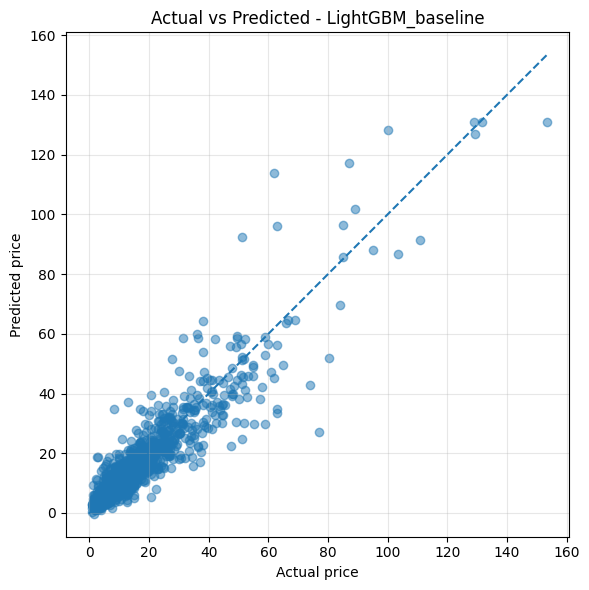

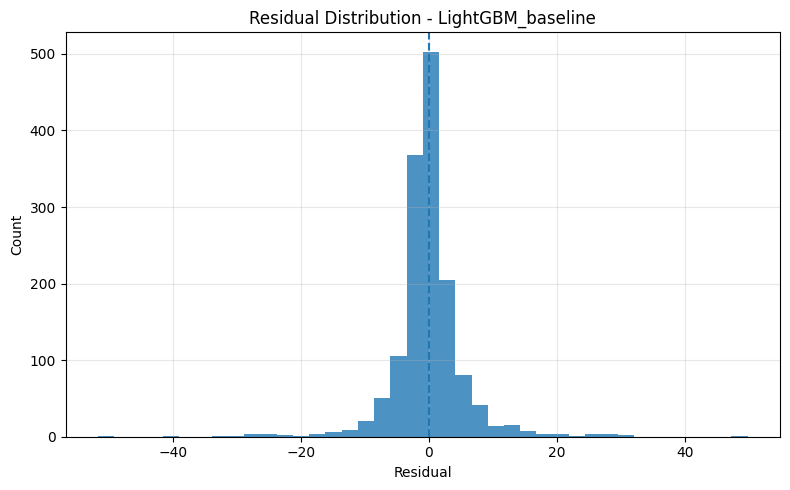

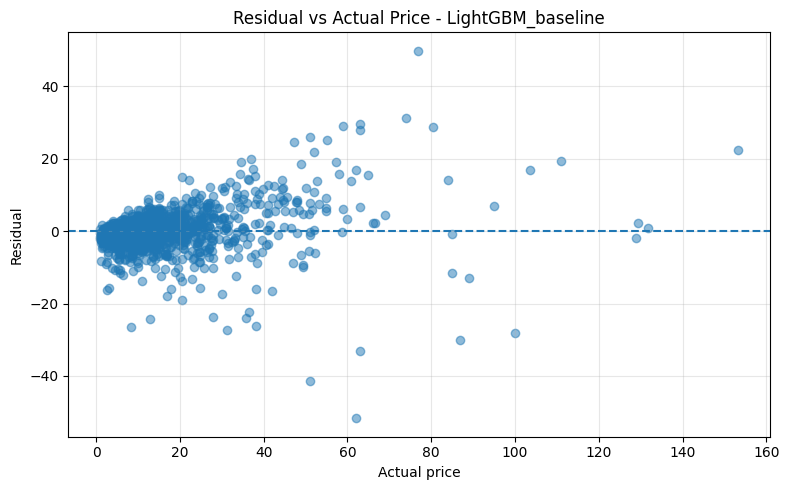

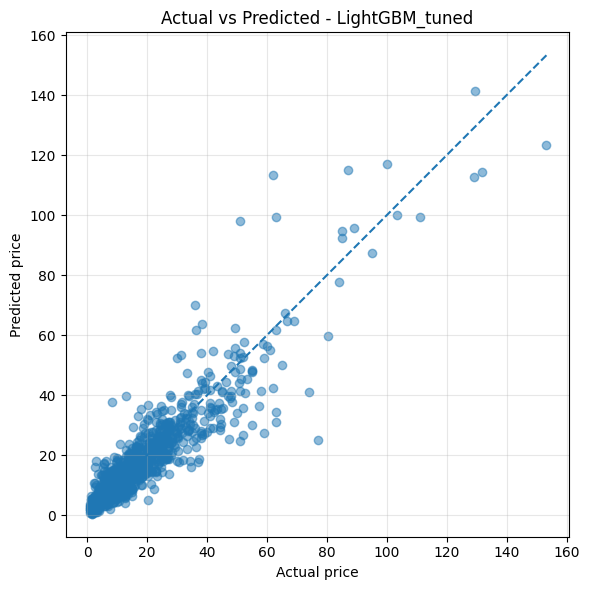

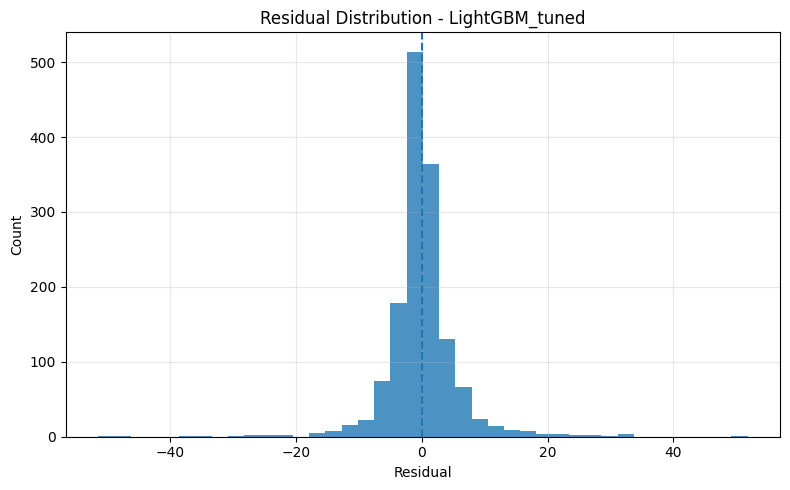

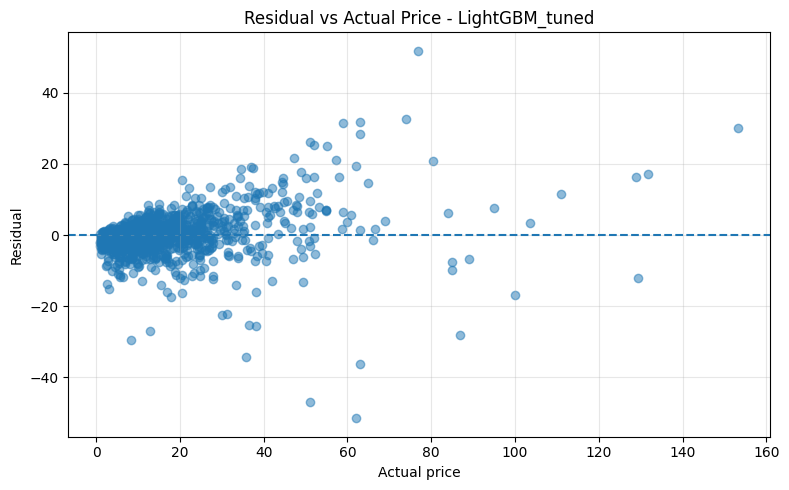

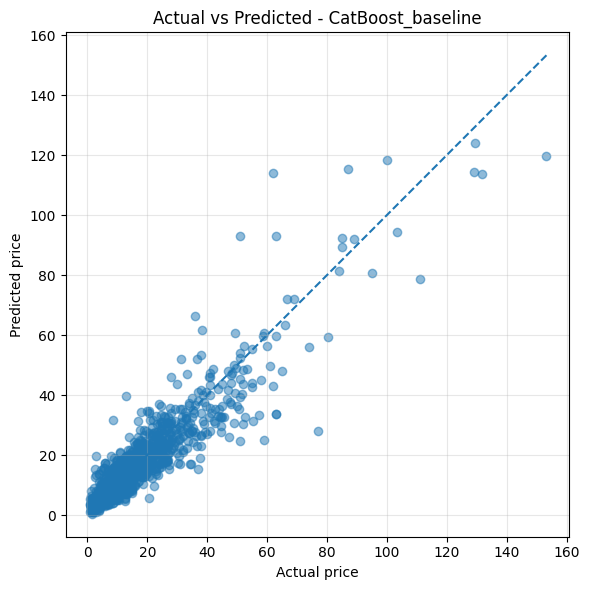

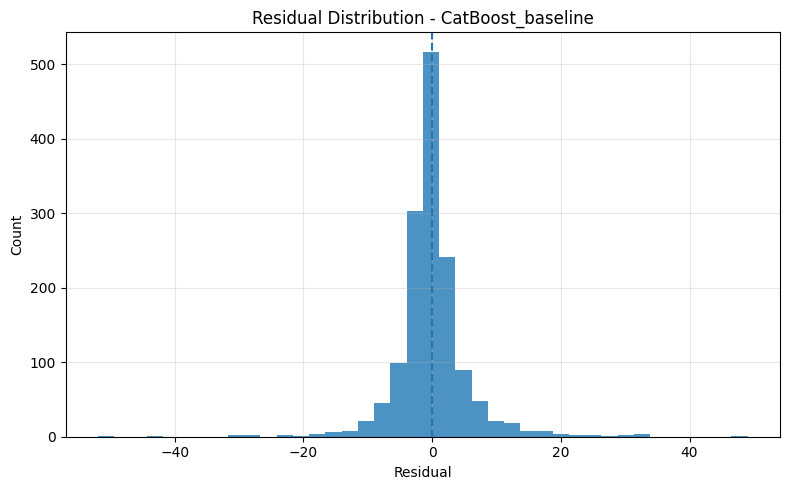

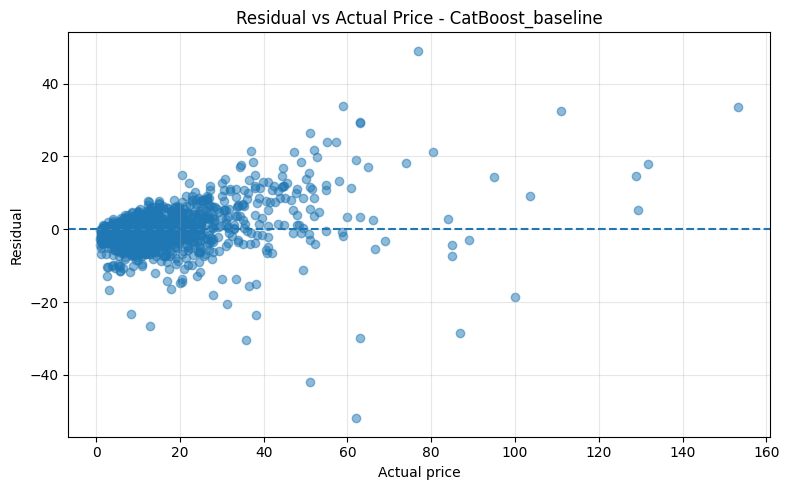

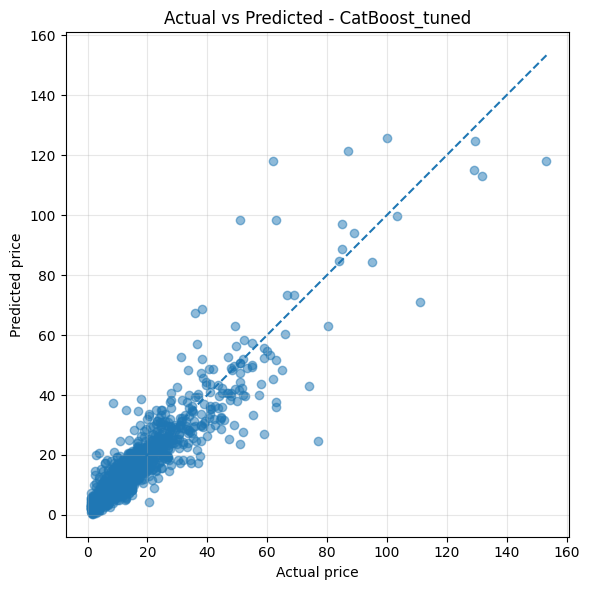

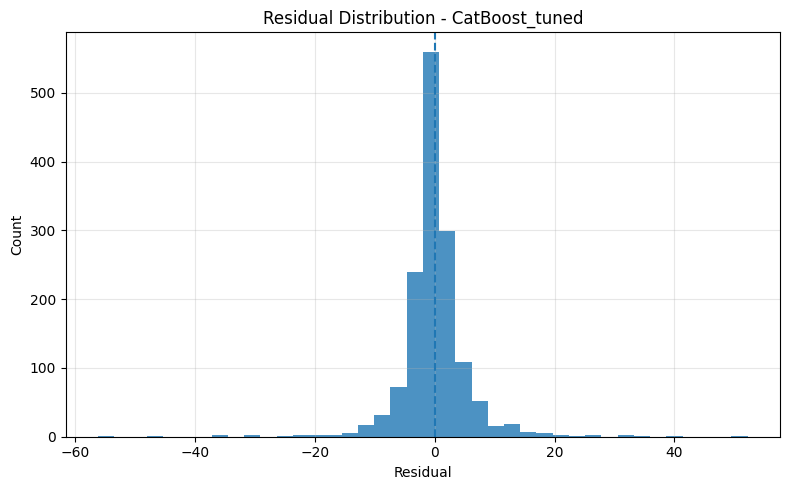

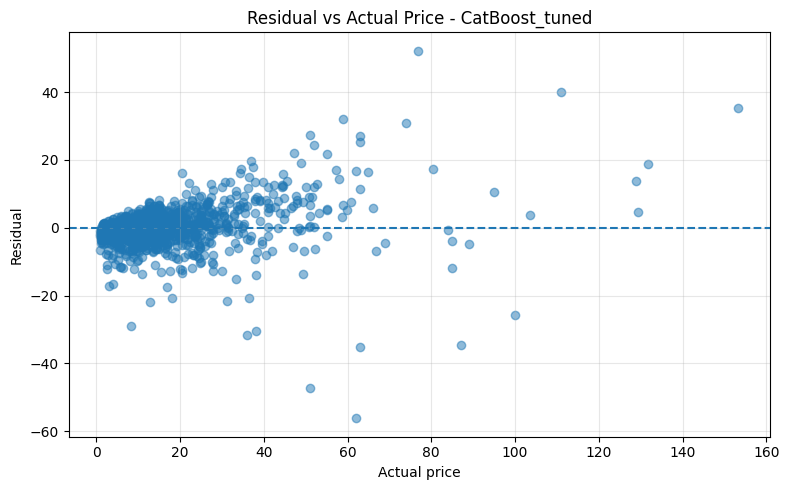

In [ ]:
def plot_actual_vs_predicted(pred_df, model_label):
    plot_df = pred_df[pred_df["model_label"] == model_label].copy()

    plt.figure(figsize=(6, 6))
    plt.scatter(plot_df["actual_price"], plot_df["predicted_price"], alpha=0.5)

    min_val = min(plot_df["actual_price"].min(), plot_df["predicted_price"].min())
    max_val = max(plot_df["actual_price"].max(), plot_df["predicted_price"].max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.title(f"Actual vs Predicted - {model_label}")
    plt.xlabel("Actual price")
    plt.ylabel("Predicted price")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    path = EVAL_PLOT_DIR / f"actual_vs_predicted_{model_label}.png"
    plt.savefig(path, dpi=150)
    plt.show()


def plot_residual_distribution(pred_df, model_label):
    plot_df = pred_df[pred_df["model_label"] == model_label].copy()

    plt.figure(figsize=(8, 5))
    plt.hist(plot_df["residual"], bins=40, alpha=0.8)
    plt.axvline(0, linestyle="--")

    plt.title(f"Residual Distribution - {model_label}")
    plt.xlabel("Residual")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    path = EVAL_PLOT_DIR / f"residual_distribution_{model_label}.png"
    plt.savefig(path, dpi=150)
    plt.show()


def plot_residual_vs_actual(pred_df, model_label):
    plot_df = pred_df[pred_df["model_label"] == model_label].copy()

    plt.figure(figsize=(8, 5))
    plt.scatter(plot_df["actual_price"], plot_df["residual"], alpha=0.5)
    plt.axhline(0, linestyle="--")

    plt.title(f"Residual vs Actual Price - {model_label}")
    plt.xlabel("Actual price")
    plt.ylabel("Residual")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    path = EVAL_PLOT_DIR / f"residual_vs_actual_{model_label}.png"
    plt.savefig(path, dpi=150)
    plt.show()


for model_label in final_predictions_df["model_label"].unique():
    plot_actual_vs_predicted(final_predictions_df, model_label)
    plot_residual_distribution(final_predictions_df, model_label)
    plot_residual_vs_actual(final_predictions_df, model_label)

## Feature Importance

In [ ]:
def get_feature_importance(model, feature_names, model_label):
    if not hasattr(model, "feature_importances_"):
        return None

    importance = model.feature_importances_

    if len(importance) != len(feature_names):
        print(
            f"Feature importance length mismatch for {model_label}: "
            f"{len(importance)} vs {len(feature_names)}"
        )
        return None

    return (
        pd.DataFrame({
            "feature": feature_names,
            "importance": importance,
            "model_label": model_label,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


fi_frames = []

for model_label, model in candidate_models.items():
    fi_df = get_feature_importance(model, feature_names, model_label)
    if fi_df is not None:
        fi_frames.append(fi_df)

if fi_frames:
    feature_importance_df = pd.concat(fi_frames, axis=0).reset_index(drop=True)
else:
    feature_importance_df = pd.DataFrame()

display(feature_importance_df.head(40))

feature_importance_df.to_csv(
    EVAL_METRIC_DIR / "feature_importance.csv",
    index=False,
)

,feature,importance,model_label
0,screen_size_inch,"1,734.0000",LightGBM_baseline
1,cpu_intel_generation_ord,"1,176.0000",LightGBM_baseline
2,ram_storage_product_scaled,"1,160.0000",LightGBM_baseline
3,cpu_tier_encoded,"1,054.0000",LightGBM_baseline
4,gpu_tier_ord_filled,887.0000,LightGBM_baseline
5,storage_gb,827.0000,LightGBM_baseline
6,ram_gb,737.0000,LightGBM_baseline
7,memory_storage_score,720.0000,LightGBM_baseline
8,cpu_family_ord_filled,651.0000,LightGBM_baseline
9,cpu_suffix_power_ord_filled,613.0000,LightGBM_baseline


## Optional SHAP For Selected Model

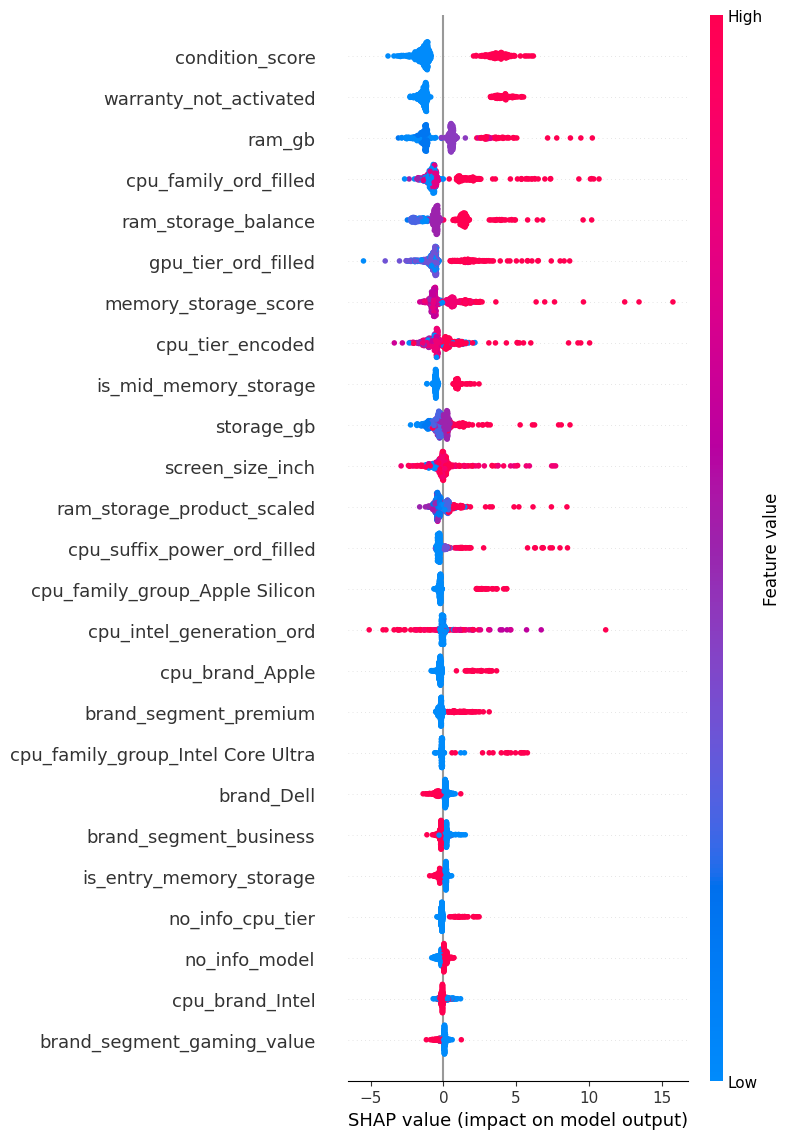

Saved SHAP summary plot to: Y:\Python\Laptop-Price-Prediction\artifacts\final_model_evaluation\plots\shap_summary_CatBoost_tuned.png


In [ ]:
try:
    import shap

    selected_model = candidate_models[selected_model_label]

    sample_X = X_test.sample(
        n=min(500, len(X_test)),
        random_state=RANDOM_STATE,
    )

    explainer = shap.TreeExplainer(selected_model)
    shap_values = explainer.shap_values(sample_X)

    shap.summary_plot(
        shap_values,
        sample_X,
        max_display=25,
        show=False,
    )

    shap_plot_path = EVAL_PLOT_DIR / f"shap_summary_{selected_model_label}.png"
    plt.tight_layout()
    plt.savefig(shap_plot_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Saved SHAP summary plot to: {shap_plot_path}")

except Exception as e:
    print(f"SHAP analysis skipped due to error: {e}")

## Final Model Decision

In [ ]:
HOLDOUT_RMSE_TOLERANCE_PCT = 3.0

selected_rmse = selected_metrics["rmse"]
best_holdout_rmse = best_holdout_metrics["rmse"]

rmse_gap_pct = (
    (selected_rmse - best_holdout_rmse)
    / best_holdout_rmse
    * 100
)

if selected_model_label == best_holdout_label:
    recommended_model_label = selected_model_label
    decision_status = "confirm_selected_model"
    decision_reason = "Selected model is also the best model on holdout RMSE."
elif rmse_gap_pct <= HOLDOUT_RMSE_TOLERANCE_PCT:
    recommended_model_label = selected_model_label
    decision_status = "keep_kfold_selected_model"
    decision_reason = (
        "Selected model is not best on holdout RMSE, but the gap is within tolerance. "
        "Keep KFold-selected model because it is more stable across folds."
    )
else:
    recommended_model_label = best_holdout_label
    decision_status = "switch_to_holdout_challenger"
    decision_reason = (
        "Selected model underperforms the best holdout model beyond tolerance. "
        "Switching to holdout challenger is recommended, but this should be reviewed with segment diagnostics."
    )

final_decision = {
    "kfold_selected_model": selected_model_label,
    "best_holdout_model": best_holdout_label,
    "recommended_final_model": recommended_model_label,
    "decision_status": decision_status,
    "decision_reason": decision_reason,
    "holdout_rmse_tolerance_pct": HOLDOUT_RMSE_TOLERANCE_PCT,
    "selected_holdout_rmse": float(selected_rmse),
    "best_holdout_rmse": float(best_holdout_rmse),
    "rmse_gap_pct": float(rmse_gap_pct),
}

final_decision_df = pd.DataFrame([final_decision])

display(final_decision_df)

final_decision_df.to_csv(
    EVAL_REPORT_DIR / "final_model_decision.csv",
    index=False,
)

with open(EVAL_REPORT_DIR / "final_model_decision.json", "w", encoding="utf-8") as f:
    json.dump(final_decision, f, indent=2, ensure_ascii=False)

,kfold_selected_model,best_holdout_model,recommended_final_model,decision_status,decision_reason,holdout_rmse_tolerance_pct,selected_holdout_rmse,best_holdout_rmse,rmse_gap_pct
0,CatBoost_tuned,LightGBM_baseline,CatBoost_tuned,keep_kfold_selected_model,"Selected model is not best on holdout RMSE, bu...",3.0000,5.9127,5.7849,2.2101


## Production Export Format

The final model is exported as a `.joblib` file because this project uses Python tree-based models such as LightGBM and CatBoost. Joblib is suitable for loading sklearn-compatible estimators in a Python backend.

The model is saved together with metadata and feature schema. The web/backend must use the same engineered numeric features and the same feature order during prediction.

## Export Production Model To Root `models/`

In [ ]:
production_model = candidate_models[recommended_model_label]

production_model_path = MODEL_DIR / "final_laptop_price_model.joblib"
production_metadata_path = MODEL_DIR / "final_laptop_price_model_metadata.json"
production_schema_path = MODEL_DIR / "final_laptop_price_feature_schema.json"

joblib.dump(production_model, production_model_path)

production_metadata = {
    "model_file": str(production_model_path),
    "model_label": recommended_model_label,
    "target": TARGET_COL,
    "prediction_unit": "same_unit_as_target_price",
    "n_features": len(feature_names),
    "feature_order_file": str(production_schema_path),
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "source_notebook": "14_final_model_evaluation.ipynb",
    "selection_basis": final_decision["decision_status"],
    "decision_reason": final_decision["decision_reason"],
    "kfold_selected_model": final_decision["kfold_selected_model"],
    "best_holdout_model": final_decision["best_holdout_model"],
    "recommended_final_model": final_decision["recommended_final_model"],
    "holdout_metrics": (
        final_holdout_metrics_df
        .set_index("model_label")
        .loc[recommended_model_label]
        .to_dict()
    ),
}

feature_schema = {
    "target": TARGET_COL,
    "n_features": len(feature_names),
    "feature_names": feature_names,
    "feature_order_required": True,
    "input_format": "pandas.DataFrame",
    "missing_feature_policy": "raise_error",
    "extra_feature_policy": "ignore_or_drop_before_prediction",
    "notes": (
        "Backend must provide features in the exact same order as feature_names. "
        "This model expects the final engineered numeric feature matrix, not raw laptop fields."
    ),
}

with open(production_metadata_path, "w", encoding="utf-8") as f:
    json.dump(production_metadata, f, indent=2, ensure_ascii=False)

with open(production_schema_path, "w", encoding="utf-8") as f:
    json.dump(feature_schema, f, indent=2, ensure_ascii=False)

print(f"Saved production model to: {production_model_path}")
print(f"Saved production metadata to: {production_metadata_path}")
print(f"Saved production feature schema to: {production_schema_path}")

Saved production model to: Y:\Python\Laptop-Price-Prediction\models\final_laptop_price_model.joblib
Saved production metadata to: Y:\Python\Laptop-Price-Prediction\models\final_laptop_price_model_metadata.json
Saved production feature schema to: Y:\Python\Laptop-Price-Prediction\models\final_laptop_price_feature_schema.json


## Production Prediction Smoke Test

In [ ]:
loaded_production_model = joblib.load(production_model_path)

sample_X = X_test.iloc[:5].copy()
sample_pred = loaded_production_model.predict(sample_X)

production_smoke_test_df = pd.DataFrame({
    "sample_index": sample_X.index,
    "prediction": sample_pred,
})

display(production_smoke_test_df)

production_smoke_test_df.to_csv(
    EVAL_REPORT_DIR / "production_model_smoke_test_predictions.csv",
    index=False,
)

,sample_index,prediction
0,2529,7.4278
1,4044,4.7529
2,3208,8.6264
3,7104,22.1819
4,6154,34.9564


In [ ]:
with open(production_schema_path, "r", encoding="utf-8") as f:
    loaded_schema = json.load(f)

assert loaded_schema["feature_names"] == feature_names
assert len(loaded_schema["feature_names"]) == sample_X.shape[1]

print("Production model smoke test passed.")

Production model smoke test passed.


## Artifact Check

In [ ]:
expected_files = [
    EVAL_METRIC_DIR / "final_holdout_metrics.csv",
    EVAL_METRIC_DIR / "selected_vs_challenger.csv",
    EVAL_METRIC_DIR / "segment_holdout_metrics.csv",
    EVAL_METRIC_DIR / "over_under_prediction_summary.csv",
    EVAL_METRIC_DIR / "feature_importance.csv",
    EVAL_PRED_DIR / "final_holdout_predictions.csv",
    EVAL_PRED_DIR / "top_error_cases.csv",
    EVAL_PRED_DIR / "top_error_cases_with_context.csv",
    EVAL_REPORT_DIR / "final_model_decision.csv",
    EVAL_REPORT_DIR / "final_model_decision.json",
    EVAL_REPORT_DIR / "production_model_smoke_test_predictions.csv",
    production_model_path,
    production_metadata_path,
    production_schema_path,
]

artifact_rows = []

for path in expected_files:
    artifact_rows.append({
        "path": str(path),
        "exists": path.exists(),
        "size_bytes": path.stat().st_size if path.exists() else 0,
    })

artifact_check_df = pd.DataFrame(artifact_rows)
display(artifact_check_df)

missing_artifacts = artifact_check_df[~artifact_check_df["exists"]]

if not missing_artifacts.empty:
    raise FileNotFoundError(
        "Missing artifacts:\n"
        + "\n".join(missing_artifacts["path"].tolist())
    )

print("All final evaluation and production artifacts are present.")

,path,exists,size_bytes
0,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,770
1,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,304
2,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,3218
3,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,830
4,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,16300
5,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,595981
6,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,8255
7,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,9354
8,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,456
9,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,528


All final evaluation and production artifacts are present.


## Final Conclusion

This notebook completed the final evaluation stage.

The final recommended model was selected by combining:

- KFold model selection from notebook 13
- independent holdout evaluation
- selected-vs-challenger comparison
- segment-level error analysis
- large-error inspection
- residual diagnostics
- feature importance / SHAP analysis

The production-ready model has been exported to:

`models/final_laptop_price_model.joblib`

The backend should also load:

`models/final_laptop_price_feature_schema.json`

to ensure that prediction input has the correct engineered feature order.

This model expects the final engineered numeric feature matrix, not raw laptop fields. If the web app receives raw fields, the same preprocessing/feature-engineering pipeline must be applied before prediction.